# EconML Example: Analyzing the Effects of Education Programs on Student Performance

**Goal.** Use the [UCI Student Performance dataset](https://archive.ics.uci.edu/dataset/320/student+performance) to estimate the **causal effect** of a school-based educational support program on students' final grades, and to explore **which student groups benefit the most**.

**Tools.**

- **EconML**: Causal inference with machine learning (treatment effect estimation).
- **ucimlrepo**: Programmatic access to the UCI ML Repository dataset.
- **Our wrapper (`econml_utils.py`)**: Utility layer to standardize how we load data and build EconML models.

This notebook is designed to be **self-contained** so a reader with no prior context could understand the dataset, the causal question, and how EconML is used here.

## 1. Notebook Summary

In this example we will:

1. **Load** the Student Performance dataset directly from the UCI ML Repository using `ucimlrepo`.
2. **Clean** and lightly encode the raw data (e.g., convert `yes`/`no` to `0`/`1`).
3. **Define the causal setup**:
   - Outcome (final grade `G3`)
   - Treatment (school support program `schoolsup`)
   - Features (X) and controls (W)
4. **Explore the data**:
   - Basic distributions of grades and key demographics
   - Differences between treated vs. control students
5. **Fit EconML models** to estimate:
   - Average Treatment Effect (ATE)
   - Heterogeneous effects (CATEs) across demographic groups.


## 2. Load the Student Performance dataset (UCI ML Repository)

We use the `ucimlrepo` Python package to download the **Student Performance** dataset
(ID = 320) directly from the UCI Machine Learning Repository.

The helper function `load_student_data()` in `econml_utils.py` wraps this logic:

- By default it calls `fetch_ucirepo(id=320)` and concatenates the features (`X`)
  and targets (`y`) into a single `pandas.DataFrame`.
- As a fallback, it can also load from a local CSV file if needed.

In [4]:
# If ucimlrepo is not already installed in the Docker image, install it.
# You can comment this out once the environment is set up.
!pip install -q ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from econml_utils import (
    load_student_data,
    clean_student_data,
    make_default_config,
    split_y_t_x_w,
    summarize_treatment,
)

In [5]:
# Load the raw dataset from UCI.
df_raw = load_student_data(source="ucimlrepo")

print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

df_raw.info()
df_raw.describe(include="all").transpose().head(15)

Raw dataset shape: (649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,GP,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,F,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,U,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,GT3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,649,2,T,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Cleaning and defining Y, T, X, W

The original dataset includes:

- Demographic and family information (e.g., `sex`, `age`, `Medu`, `Fedu`)
- Study behavior and school-related variables (e.g., `studytime`, `absences`)
- Several support flags:
  - `schoolsup`: extra educational school support (yes/no)
  - `famsup`: family educational support (yes/no)
  - `paid`: extra paid classes (yes/no)
- Three grade columns:
  - `G1`, `G2`: first and second period grades
  - `G3`: final grade

For this project we adopt the following **causal framing**:

- **Outcome (Y)**: `G3` - the final course grade.
- **Treatment (T)**: `schoolsup` - interpreted as participation in a school support program.
- **Features (X)** (treatment-effect heterogeneity):
  - `sex`, `age`, `Medu`, `Fedu`, `studytime`, `failures`, `higher`, `internet`, `absences`
- **Controls (W)** (confounding adjustment):
  - `G1`, `G2`, `famsup`, `paid`

The function `clean_student_data()`:

- Converts `yes`/`no` flags to 0/1
- Encodes a few categorical variables as 0/1 (e.g., `sex`, `school`, `address`, `Pstatus`)

The helper `make_default_config()` stores these column choices in an
`EconMLEducationConfig` object that we will pass to EconML later.

In [6]:
# Clean the raw data (e.g., map yes/no to 0/1, encode a few key categories).
df = clean_student_data(df_raw)

# Build the default causal configuration (Y, T, X, W).
config = make_default_config()
config

EconMLEducationConfig(outcome_col='G3', treatment_col='schoolsup', x_cols=['sex', 'age', 'Medu', 'Fedu', 'studytime', 'failures', 'higher', 'internet', 'absences'], w_cols=['G1', 'G2', 'famsup', 'paid'], estimator_type='linear_dml')

In [7]:
# How many treated vs control students, and what are their average final grades?
treatment_summary = summarize_treatment(df, config)
treatment_summary

,treatment,count,mean_outcome,std_outcome
0,0,581,11.979346,3.316040
1,1,68,11.279412,2.304088


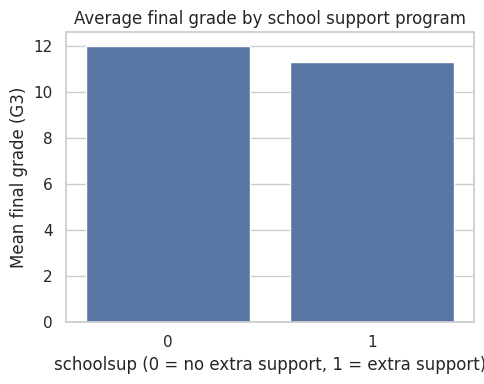

In [8]:
plt.figure(figsize=(5, 4))
sns.barplot(
    data=treatment_summary,
    x="treatment",
    y="mean_outcome",
)
plt.xlabel("schoolsup (0 = no extra support, 1 = extra support)")
plt.ylabel("Mean final grade (G3)")
plt.title("Average final grade by school support program")
plt.tight_layout()
plt.show()